# PROJET NLP & INFORMATION RETRIEVAL BY BOULMIER Ilan & COLIN De Verdière Thomas

## PARTIE III : embeddings 


Cette Partie couvre :
1. Entraînement d'un modèle Word2Vec sur nos avis
2. Utilisation de GloVe pré-entraîné
3. Distance euclidienne et cosinus entre mots
4. Recherche sémantique (semantic search)
5. Visualisation avec Matplotlib (PCA/TSNE) et TensorBoard

## 0. Imports et configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import warnings
warnings.filterwarnings('ignore')

# Word2Vec
# pip install gensim
from gensim.models import Word2Vec, KeyedVectors

# TensorBoard
import os
import tensorflow as tf
from tensorboard.plugins import projector

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 7)

print('✅ Imports OK')
print('⚠️  Si erreur : pip install gensim tensorflow tensorboard')

✅ Imports OK
⚠️  Si erreur : pip install gensim tensorflow tensorboard


## 1. Chargement des données

In [5]:
df_train = pd.read_csv('avis_train_clean.csv')
df_test  = pd.read_csv('avis_test_clean.csv')

print(f'Train : {len(df_train):,} avis')
print(f'Test  : {len(df_test):,} avis')

# Tokenisation : liste de listes de mots
# On utilise avis_clean (stopwords supprimés) pour Word2Vec
sentences_train = [str(text).split() for text in df_train['avis_clean'].dropna()]
sentences_all   = sentences_train + [str(text).split() for text in df_test['avis_clean'].dropna()]

print(f'Nombre de phrases pour Word2Vec : {len(sentences_all):,}')
print(f'Exemple : {sentences_all[0][:10]}')

Train : 24,104 avis
Test  : 10,331 avis
Nombre de phrases pour Word2Vec : 34,430
Exemple : ['personne', 'téléphone', 'clair', 'sympathique', 'expliqué', 'recommanderai', 'sans', 'hésitation', 'merci', 'personne']


## 2. Entraînement Word2Vec

In [6]:
# Entraînement Word2Vec sur nos avis clients
print('Entraînement Word2Vec...')

w2v_model = Word2Vec(
    sentences=sentences_all,
    vector_size=100,    # Dimension des vecteurs
    window=5,           # Contexte : 5 mots avant/après
    min_count=3,        # Ignorer les mots apparaissant < 3 fois
    workers=4,          # Parallélisation
    sg=1,               # 1=Skip-gram, 0=CBOW
    epochs=10,
    seed=42
)

print(f'✅ Word2Vec entraîné !')
print(f'Vocabulaire : {len(w2v_model.wv):,} mots')

# Sauvegarde
os.makedirs('models', exist_ok=True)
w2v_model.save('models/word2vec_avis.model')
print('💾 Modèle sauvegardé : models/word2vec_avis.model')

Entraînement Word2Vec...
✅ Word2Vec entraîné !
Vocabulaire : 14,083 mots
💾 Modèle sauvegardé : models/word2vec_avis.model


In [7]:
# Exploration du modèle Word2Vec
wv = w2v_model.wv

# Mots similaires
mots_test = ['remboursement', 'sinistre', 'résiliation', 'conseiller', 'prix']

for mot in mots_test:
    if mot in wv:
        similaires = wv.most_similar(mot, topn=5)
        print(f'\n🔍 Mots proches de "{mot}" :')
        for w, score in similaires:
            print(f'   {w:<20} similarité cosinus : {score:.4f}')
    else:
        print(f'⚠️  "{mot}" absent du vocabulaire')


🔍 Mots proches de "remboursement" :
   remboursements       similarité cosinus : 0.6816
   remboursé            similarité cosinus : 0.6699
   lentilles            similarité cosinus : 0.6459
   rembousement         similarité cosinus : 0.6404
   remboursés           similarité cosinus : 0.6367

🔍 Mots proches de "sinistre" :
   sinistres            similarité cosinus : 0.7392
   sinsitre             similarité cosinus : 0.6976
   accident             similarité cosinus : 0.6970
   dégat                similarité cosinus : 0.6909
   sinitre              similarité cosinus : 0.6750

🔍 Mots proches de "résiliation" :
   résiliations         similarité cosinus : 0.6969
   résilier             similarité cosinus : 0.6711
   chatel               similarité cosinus : 0.6587
   annulation           similarité cosinus : 0.6515
   fichage              similarité cosinus : 0.6455

🔍 Mots proches de "conseiller" :
   conseillé            similarité cosinus : 0.8036
   conseillère          simila

In [8]:
# Analogies (king - man + woman = queen)
print('=== Analogies Word2Vec ===')
analogies = [
    (['rapide', 'service'], ['lent'], 'rapide - lent + service = ?'),
    (['remboursement', 'rapide'], ['lent'], 'remboursement + rapide - lent = ?'),
]

for positif, negatif, label in analogies:
    try:
        # Filtrer les mots présents dans le vocabulaire
        pos = [w for w in positif if w in wv]
        neg = [w for w in negatif if w in wv]
        if pos:
            result = wv.most_similar(positive=pos, negative=neg, topn=3)
            print(f'\n{label}')
            for w, s in result:
                print(f'   → {w} ({s:.3f})')
    except Exception as e:
        print(f'⚠️  Erreur pour {label}: {e}')

=== Analogies Word2Vec ===

rapide - lent + service = ?
   → direct-assurance (0.733)
   → raide (0.698)
   → resonable (0.695)

remboursement + rapide - lent = ?
   → economie (0.589)
   → nickel (0.583)
   → achats (0.582)


## 3. Distance euclidienne et cosinus

In [9]:
def distance_cosinus(mot1, mot2, model):
    """Similarité cosinus entre deux mots (plus proche de 1 = plus similaire)."""
    if mot1 not in model or mot2 not in model:
        return None
    v1 = model[mot1].reshape(1, -1)
    v2 = model[mot2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

def distance_euclidienne(mot1, mot2, model):
    """Distance euclidienne entre deux mots (plus proche de 0 = plus similaire)."""
    if mot1 not in model or mot2 not in model:
        return None
    v1 = model[mot1].reshape(1, -1)
    v2 = model[mot2].reshape(1, -1)
    return float(euclidean_distances(v1, v2)[0][0])

# Tableau comparatif
paires = [
    ('remboursement', 'paiement'),
    ('remboursement', 'sinistre'),
    ('service', 'conseiller'),
    ('rapide', 'lent'),
    ('rapide', 'efficace'),
    ('assurance', 'contrat'),
]

print(f'{"Paire":<40} {"Cosinus":>10} {"Euclidien":>12}')
print('-' * 65)
for m1, m2 in paires:
    cos = distance_cosinus(m1, m2, wv)
    euc = distance_euclidienne(m1, m2, wv)
    if cos is not None:
        print(f'{m1} ↔ {m2:<28} {cos:>10.4f} {euc:>12.4f}')
    else:
        print(f'{m1} ↔ {m2:<28} (mots absents du vocabulaire)')

Paire                                       Cosinus    Euclidien
-----------------------------------------------------------------
remboursement ↔ paiement                         0.4081       3.5338
remboursement ↔ sinistre                         0.2413       3.6693
service ↔ conseiller                       0.5716       2.6472
rapide ↔ lent                             0.4065       3.5769
rapide ↔ efficace                         0.7627       2.4854
assurance ↔ contrat                      (mots absents du vocabulaire)


## 4. Visualisation avec Matplotlib (PCA + t-SNE)

In [10]:
# Groupes de mots thématiques à visualiser
groupes = {
    'Service client': ['conseiller', 'téléphone', 'accueil', 'réponse', 'appel', 'contact'],
    'Prix':          ['prix', 'tarif', 'coût', 'cotisation', 'cher', 'économique'],
    'Remboursement': ['remboursement', 'paiement', 'virement', 'délai', 'versement'],
    'Sinistre':      ['sinistre', 'accident', 'dommage', 'réparation', 'expertise'],
    'Sentiment +':   ['excellent', 'parfait', 'satisfait', 'recommande', 'efficace'],
    'Sentiment -':   ['déçu', 'nul', 'honte', 'arnaque', 'scandale', 'problème'],
}

# Filtrer les mots présents dans le vocabulaire
words_to_plot = []
labels = []
colors_map = []
palette = sns.color_palette('tab10', len(groupes))

for i, (groupe, mots) in enumerate(groupes.items()):
    for mot in mots:
        if mot in wv:
            words_to_plot.append(mot)
            labels.append(groupe)
            colors_map.append(palette[i])

print(f'{len(words_to_plot)} mots trouvés dans le vocabulaire sur {sum(len(v) for v in groupes.values())} demandés')

# Récupérer les vecteurs
vectors = np.array([wv[w] for w in words_to_plot])

33 mots trouvés dans le vocabulaire sur 33 demandés


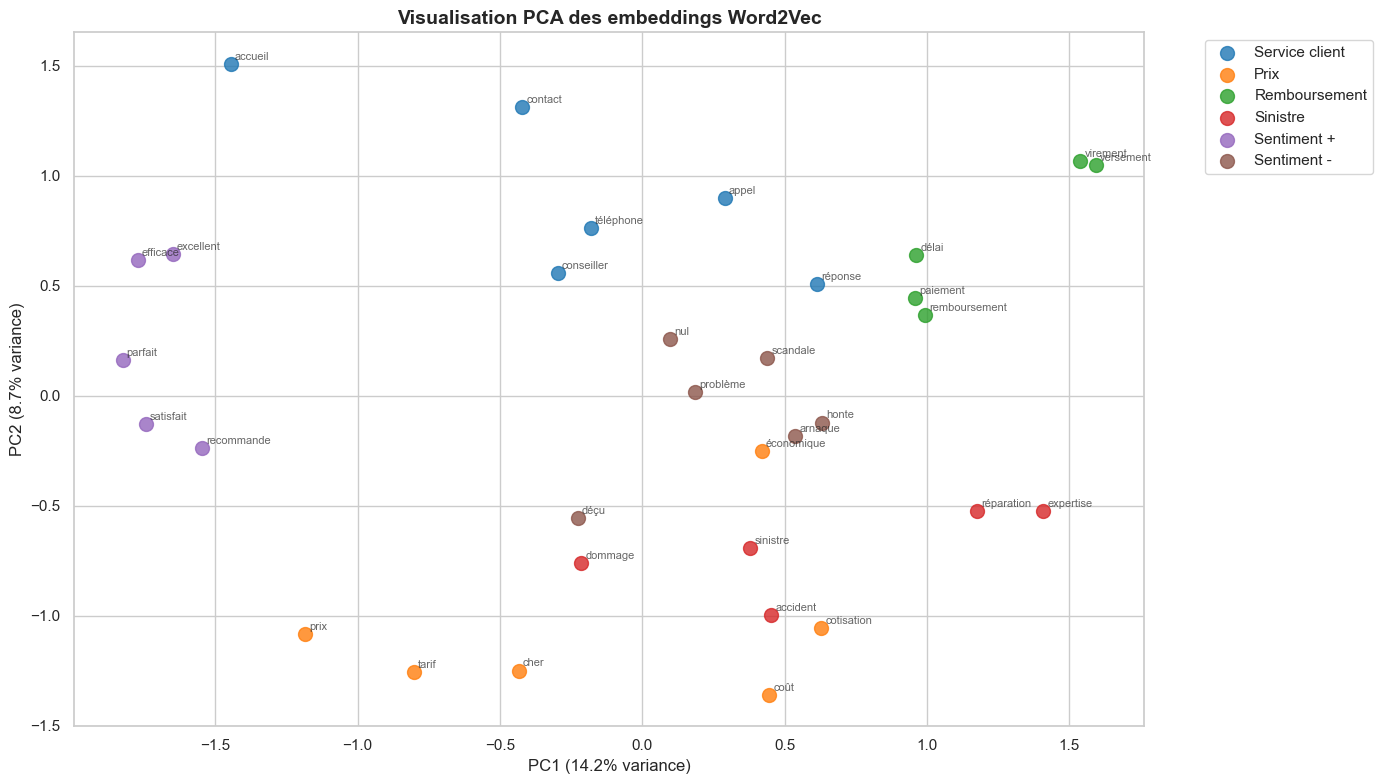

In [11]:
# Visualisation PCA 2D
pca = PCA(n_components=2, random_state=42)
vectors_2d_pca = pca.fit_transform(vectors)

plt.figure(figsize=(14, 8))
for i, (groupe, color) in enumerate(zip(groupes.keys(), palette)):
    mask = [l == groupe for l in labels]
    pts = vectors_2d_pca[mask]
    plt.scatter(pts[:, 0], pts[:, 1], c=[color], label=groupe, s=100, alpha=0.8)

# Annotations
for j, (word, pt) in enumerate(zip(words_to_plot, vectors_2d_pca)):
    plt.annotate(word, pt, fontsize=8, alpha=0.7,
                 xytext=(3, 3), textcoords='offset points')

plt.title('Visualisation PCA des embeddings Word2Vec', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('embeddings_pca.png', dpi=150, bbox_inches='tight')
plt.show()

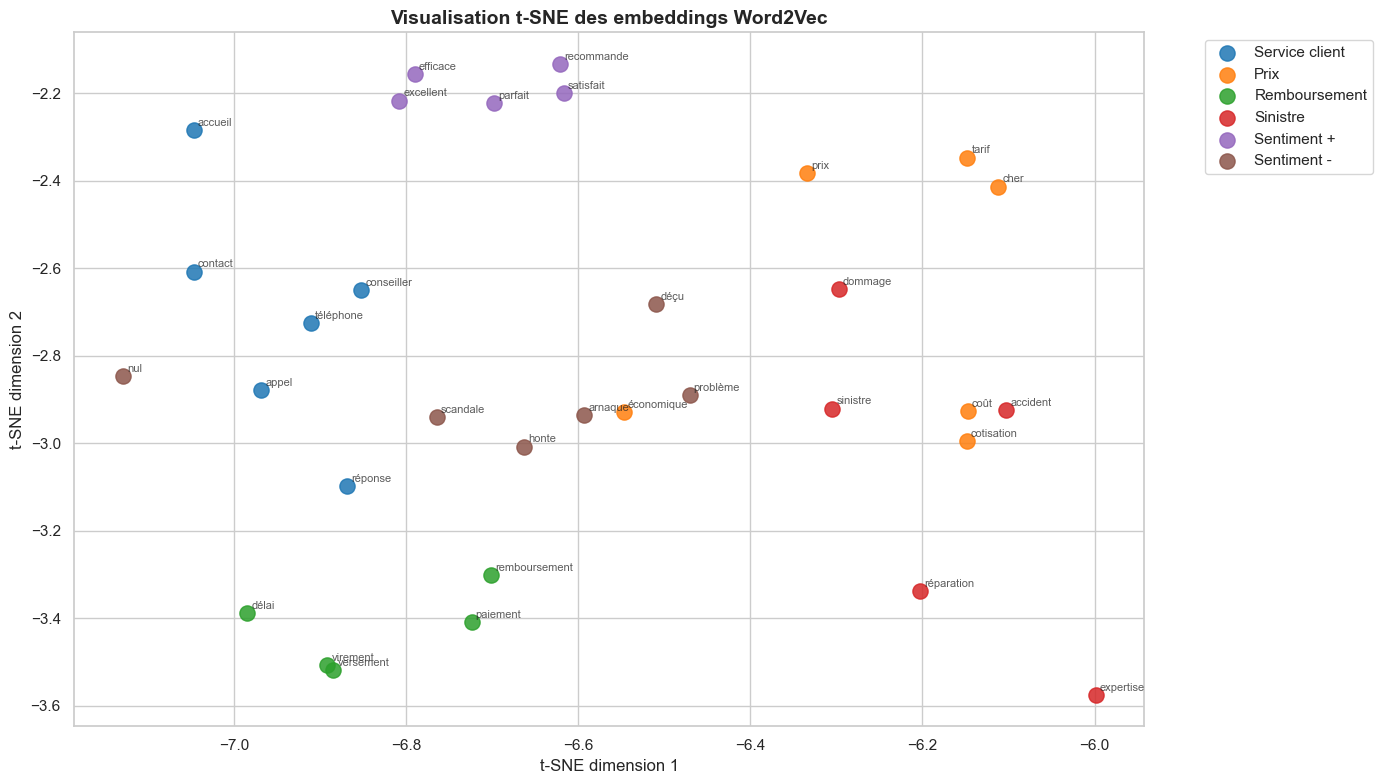

In [13]:
# Visualisation t-SNE 2D (meilleure séparation des clusters)
# Note : t-SNE est stochastique, les résultats varient légèrement
perplexity = min(30, len(words_to_plot) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=1000)
vectors_2d_tsne = tsne.fit_transform(vectors)

plt.figure(figsize=(14, 8))
for i, (groupe, color) in enumerate(zip(groupes.keys(), palette)):
    mask = [l == groupe for l in labels]
    pts = vectors_2d_tsne[mask]
    plt.scatter(pts[:, 0], pts[:, 1], c=[color], label=groupe, s=120, alpha=0.85)

for j, (word, pt) in enumerate(zip(words_to_plot, vectors_2d_tsne)):
    plt.annotate(word, pt, fontsize=8, alpha=0.75,
                 xytext=(3, 3), textcoords='offset points')

plt.title('Visualisation t-SNE des embeddings Word2Vec', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('embeddings_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Visualisation TensorBoard

In [14]:
# Export des embeddings pour TensorBoard Projector
# Visualisation interactive 3D sur : https://projector.tensorflow.org/

TB_LOG_DIR = 'tensorboard_embeddings'
os.makedirs(TB_LOG_DIR, exist_ok=True)

# Prendre les N mots les plus fréquents du vocabulaire
N_WORDS = 1000
vocab_words = list(wv.key_to_index.keys())[:N_WORDS]
vocab_vectors = np.array([wv[w] for w in vocab_words])

# 1. Sauvegarder les vecteurs (tensors.tsv)
with open(os.path.join(TB_LOG_DIR, 'tensors.tsv'), 'w', encoding='utf-8') as f:
    for vec in vocab_vectors:
        f.write('\t'.join([str(x) for x in vec]) + '\n')

# 2. Sauvegarder les métadonnées (metadata.tsv) — les mots
with open(os.path.join(TB_LOG_DIR, 'metadata.tsv'), 'w', encoding='utf-8') as f:
    f.write('Word\n')
    for word in vocab_words:
        f.write(word + '\n')

# 3. Créer le checkpoint TensorFlow
weights = tf.Variable(vocab_vectors, trainable=False, name='word_embeddings')
checkpoint = tf.train.Checkpoint(embedding=weights)
checkpoint.save(os.path.join(TB_LOG_DIR, 'embedding.ckpt'))

# 4. Configurer le projector
config = projector.ProjectorConfig()
embedding = config.embeddings.add()
embedding.tensor_name = 'embedding/.ATTRIBUTES/VARIABLE_VALUE'
embedding.metadata_path = 'metadata.tsv'
projector.visualize_embeddings(TB_LOG_DIR, config)

print(f'✅ Embeddings exportés dans : {TB_LOG_DIR}/')
print(f'   - tensors.tsv ({N_WORDS} mots x 100 dims)')
print(f'   - metadata.tsv (labels des mots)')
print()
print('Pour lancer TensorBoard, exécutez dans un terminal :')
print(f'   tensorboard --logdir={TB_LOG_DIR}')
print()
print('Ou dans Jupyter :')
print('   %load_ext tensorboard')
print(f'   %tensorboard --logdir {TB_LOG_DIR}')

✅ Embeddings exportés dans : tensorboard_embeddings/
   - tensors.tsv (1000 mots x 100 dims)
   - metadata.tsv (labels des mots)

Pour lancer TensorBoard, exécutez dans un terminal :
   tensorboard --logdir=tensorboard_embeddings

Ou dans Jupyter :
   %load_ext tensorboard
   %tensorboard --logdir tensorboard_embeddings


In [ ]:
# Lancer TensorBoard directement dans Jupyter (optionnel)
%load_ext tensorboard
%tensorboard --logdir tensorboard_embeddings

## 6. GloVe pré-entraîné

In [15]:
# GloVe : utilisation des vecteurs pré-entraînés via gensim
# Option 1 : télécharger via gensim downloader (anglais)
# Option 2 : charger un fichier GloVe local (français)

# --- Option 1 : GloVe anglais via gensim (recommandé, simple) ---
import gensim.downloader as api

print('Chargement de GloVe 50d (anglais, ~170MB)...')
print('⚠️  Première exécution = téléchargement (~2 min)')

glove_model = api.load('glove-wiki-gigaword-50')  # 50 dimensions
print(f'✅ GloVe chargé : {len(glove_model):,} mots, 50 dimensions')

Chargement de GloVe 50d (anglais, ~170MB)...
⚠️  Première exécution = téléchargement (~2 min)
[==================================================] 100.0% 66.0/66.0MB downloaded
✅ GloVe chargé : 400,000 mots, 50 dimensions


In [16]:
# Exploration GloVe (sur les avis traduits en anglais : colonne avis_en)
print('=== Exploration GloVe (anglais) ===')

mots_en = ['insurance', 'claim', 'service', 'price', 'refund', 'cancel']
for mot in mots_en:
    if mot in glove_model:
        similaires = glove_model.most_similar(mot, topn=5)
        print(f'\n🔍 Mots proches de "{mot}" (GloVe) :')
        for w, score in similaires:
            print(f'   {w:<20} {score:.4f}')

=== Exploration GloVe (anglais) ===

🔍 Mots proches de "insurance" (GloVe) :
   pension              0.8642
   insurers             0.8631
   credit               0.8330
   premiums             0.8076
   employer             0.8068

🔍 Mots proches de "claim" (GloVe) :
   claiming             0.9168
   claims               0.9129
   claimed              0.8332
   deny                 0.8177
   denying              0.7775

🔍 Mots proches de "service" (GloVe) :
   services             0.9041
   provided             0.7984
   private              0.7883
   travel               0.7650
   provides             0.7632

🔍 Mots proches de "price" (GloVe) :
   prices               0.9087
   sales                0.8436
   market               0.8383
   drop                 0.8383
   stock                0.8372

🔍 Mots proches de "refund" (GloVe) :
   refunds              0.9187
   payment              0.8112
   reimbursement        0.7658
   payments             0.7575
   fees                 0.75

In [17]:
# Comparaison Word2Vec (entraîné sur nos données) vs GloVe (pré-entraîné)
print('=== Comparaison Word2Vec vs GloVe ===')
print(f'{"Paire":<30} {"Word2Vec":>12} {"GloVe (EN)":>12}')
print('-' * 58)

# Paires FR pour Word2Vec, EN pour GloVe
comparaisons = [
    ('remboursement', 'paiement', 'refund', 'payment'),
    ('service', 'conseiller', 'service', 'advisor'),
    ('rapide', 'efficace', 'fast', 'efficient'),
]

for m1_fr, m2_fr, m1_en, m2_en in comparaisons:
    cos_w2v = distance_cosinus(m1_fr, m2_fr, wv)
    cos_glove = distance_cosinus(m1_en, m2_en, glove_model)
    label = f'{m1_fr}/{m2_fr}'
    w2v_str   = f'{cos_w2v:.4f}'   if cos_w2v   else 'N/A'
    glove_str = f'{cos_glove:.4f}' if cos_glove else 'N/A'
    print(f'{label:<30} {w2v_str:>12} {glove_str:>12}')

=== Comparaison Word2Vec vs GloVe ===
Paire                              Word2Vec   GloVe (EN)
----------------------------------------------------------
remboursement/paiement               0.4081       0.8112
service/conseiller                   0.5716       0.3999
rapide/efficace                      0.7627       0.6756


## 7. Recherche sémantique (Bonus)

In [18]:
# Recherche sémantique : trouver les avis les plus similaires à une requête
# Principe : représenter chaque avis par la moyenne de ses vecteurs de mots

def text_to_vector(text, model, vector_size=100):
    """Représente un texte par la moyenne de ses vecteurs de mots."""
    words = str(text).split()
    vectors = [model[w] for w in words if w in model]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

print('Calcul des vecteurs moyens pour tous les avis (train)...')
# Utiliser un sous-ensemble pour la démo
SAMPLE = 5000
df_sample = df_train.sample(SAMPLE, random_state=42).reset_index(drop=True)

doc_vectors = np.array([
    text_to_vector(text, wv)
    for text in df_sample['avis_clean']
])

print(f'✅ {len(doc_vectors)} vecteurs calculés, shape: {doc_vectors.shape}')

Calcul des vecteurs moyens pour tous les avis (train)...
✅ 5000 vecteurs calculés, shape: (5000, 100)


In [19]:
def semantic_search(query, doc_vectors, df, model, top_k=5):
    """
    Recherche sémantique : retourne les top_k avis les plus similaires à la requête.
    """
    # Nettoyer et vectoriser la requête
    import re
    query_clean = re.sub(r'[^\w\s]', ' ', query.lower())
    query_vec = text_to_vector(query_clean, model).reshape(1, -1)
    
    # Calculer les similarités cosinus
    sims = cosine_similarity(query_vec, doc_vectors)[0]
    
    # Top k résultats
    top_indices = sims.argsort()[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        results.append({
            'score': sims[idx],
            'note': df.iloc[idx]['note'],
            'assureur': df.iloc[idx]['assureur'],
            'avis': df.iloc[idx]['avis'][:200]
        })
    return results

# Tests de recherche sémantique
requetes = [
    "remboursement lent et service médiocre",
    "excellent service client très réactif",
    "résiliation difficile et arnaque"
]

for requete in requetes:
    print(f'\n Requête : "{requete}"')
    print('-' * 70)
    results = semantic_search(requete, doc_vectors, df_sample, wv, top_k=3)
    for i, r in enumerate(results, 1):
        print(f'  [{i}] Score: {r["score"]:.3f} | Note: {r["note"]}★ | {r["assureur"]}')
        print(f'      "{r["avis"]}..."')


🔍 Requête : "remboursement lent et service médiocre"
----------------------------------------------------------------------
  [1] Score: 0.867 | Note: 1.0★ | Mercer
      "Service déplorable quasi inexistant on ne peut les joindre que rarement. Les remboursements sont longs à traiter. Mutuelle à éviter..."
  [2] Score: 0.854 | Note: 1.0★ | Allianz
      "Service clientèle médiocre. Quand il y a pb, très difficile de le traiter..."
  [3] Score: 0.841 | Note: 1.0★ | L'olivier Assurance
      "Très mauvaise assurance !
Vous avez le minimum de service en temps normal et lors de la gestion du sinistre, catastrophique !!! 2 mois et toujours pas de réponse. Soi disant qu'on attend le retour des..."

🔍 Requête : "excellent service client très réactif"
----------------------------------------------------------------------
  [1] Score: 0.931 | Note: 4.0★ | MGP
      "Service client à l'écoute et très professionnel...."
  [2] Score: 0.919 | Note: 5.0★ | L'olivier Assurance
      "Service client 

## 8. Sauvegarde des vecteurs de documents

In [21]:
# Calculer les vecteurs moyens pour TOUT le train (utile pour le notebook 04)
print('Calcul des vecteurs pour tout le train...')

all_doc_vectors = np.array([
    text_to_vector(text, wv)
    for text in df_train['avis_clean']
])

np.save('w2v_train_vectors.npy', all_doc_vectors)
print(f' Sauvegardé : data/w2v_train_vectors.npy')
print(f'   Shape : {all_doc_vectors.shape}')

# Idem pour le test
all_test_vectors = np.array([
    text_to_vector(text, wv)
    for text in df_test['avis_clean']
])
np.save('w2v_test_vectors.npy', all_test_vectors)
print(f' Sauvegardé : data/w2v_test_vectors.npy')

print()
print('Prochaine étape : Notebook 04 — Modèles supervisés')

Calcul des vecteurs pour tout le train...
✅ Sauvegardé : data/w2v_train_vectors.npy
   Shape : (24104, 100)
✅ Sauvegardé : data/w2v_test_vectors.npy

Prochaine étape : Notebook 04 — Modèles supervisés
